# Beyond BLAST

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Base.Threads
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Dates
using TOML
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using JSON

include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials;

In [133]:
include("blast_code/src/galaxy_galaxy.jl")
using .galaxy_galaxy

In [70]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
quantity_subdir = joinpath(output_dir, "quantities")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_12_104704, out/runs/run_2026_06_12_104704/plots and out/runs/run_2026_06_12_104704/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [131]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

#### Setting parameters

In [ ]:
cosmo = Blast.FlatΛCDM()
n_chi = 96                                            # Number of comoving distance points
x_range = LinRange(26, 7000, n_chi)
z_range = z_of_χ.(x_range)
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
x_min = minimum(x_range)                              # minimum comoving distance [Mpc/h]
x_max = maximum(x_range)                              # maximum comoving distance [Mpc/h]
chi = LinRange(x_min, x_max, n_chi)                   # array of comoving distances [Mpc/h]
zed = z_of_χ.(chi)                                    # array of redshifts corresponding to the comoving distances
n_z = length(zed)
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^15+1;

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_0^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

In [112]:
gal_prefact_W, bias, growth, inv_Hubble, nz = galaxy_galaxy.galaxy_prefactor(x_range, z_range, cosmo; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_12_104704/plots/chi_vs_z.png
Plot saved: out/runs/run_2026_06_12_104704/plots/bias.png
Plot saved: out/runs/run_2026_06_12_104704/plots/growth.png
Plot saved: out/runs/run_2026_06_12_104704/plots/inv_hubble.png
Plot saved: out/runs/run_2026_06_12_104704/plots/nz.png
Plot saved: out/runs/run_2026_06_12_104704/plots/Wz.png
Plot saved: out/runs/run_2026_06_12_104704/plots/normalized_quantities.png
Wrote W(z) prefactor to: out/runs/run_2026_06_12_104704/quantities/prefac.npy


In [134]:
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z_range, chi, bias, growth, inv_Hubble, nz; output_dir=output_dir);

Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_12_104704/quantities/prefac_cheb.npy


In [ ]:
W_vals = gal_prefact_W_cheb
plan = Blast.plan_fft(W_vals)
cheb_coeff = Blast.fast_chebcoefs(W_vals, plan)
npzwrite(joinpath(output_dir, "quantities/W_cheb_coeff.npy"), cheb_coeff)
println("Wrote W(z) Chebyshev coefficients to: ", joinpath(output_dir, "quantities/W_cheb_coeff.npy"))
true_n_cheb = length(cheb_coeff); 

Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_12_104704/quantities/W_cheb_coeff.npy


In [33]:
W_tilde = zeros(length(ℓ), length(z_range), length(z_range), true_n_cheb)
for i in eachindex(ℓ)
    W_tilde[i,:,:,:] = Blast.compute_W_tilde(ℓ[i], zmin, zmax, kmin, kmax, z_range, n_cheb-1, N, chi_of_z)
    println("Finished computing W_tilde for ℓ = $(ℓ[i]) at $(Dates.now())")
end

Finished computing W_tilde for ℓ = 2.0 at 2026-06-12T10:01:44.954
Finished computing W_tilde for ℓ = 4.0 at 2026-06-12T10:01:44.968
Finished computing W_tilde for ℓ = 6.0 at 2026-06-12T10:01:44.980
Finished computing W_tilde for ℓ = 8.0 at 2026-06-12T10:01:44.993
Finished computing W_tilde for ℓ = 10.0 at 2026-06-12T10:01:45.004
Finished computing W_tilde for ℓ = 12.0 at 2026-06-12T10:01:45.015
Finished computing W_tilde for ℓ = 14.0 at 2026-06-12T10:01:45.025
Finished computing W_tilde for ℓ = 15.999999999999998 at 2026-06-12T10:01:45.035
Finished computing W_tilde for ℓ = 18.0 at 2026-06-12T10:01:45.045
Finished computing W_tilde for ℓ = 20.0 at 2026-06-12T10:01:45.056
Finished computing W_tilde for ℓ = 22.0 at 2026-06-12T10:01:45.071
Finished computing W_tilde for ℓ = 24.0 at 2026-06-12T10:01:45.114
Finished computing W_tilde for ℓ = 26.0 at 2026-06-12T10:01:45.127
Finished computing W_tilde for ℓ = 28.000000000000004 at 2026-06-12T10:01:45.139
Finished computing W_tilde for ℓ = 29.

In [34]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [35]:
println("Size of W_tilde: ", size(W_tilde))
println(size(W_vals))
println("size of cheb_coeff: ", size(cheb_coeff))
println("size of W_tilde: ", size(W_tilde))

Size of W_tilde: (100, 96, 96, 119)
(119,)
size of cheb_coeff: (119,)
size of W_tilde: (100, 96, 96, 119)


In [36]:
npzwrite(joinpath(output_dir, "cheb_coeff.npy"), cheb_coeff)

In [37]:
@tullio W_final[i, j, k] := W_tilde[i, j, k, l] * cheb_coeff[l];

In [38]:
npzwrite(joinpath(output_dir, "W_final.npy"), W_final)

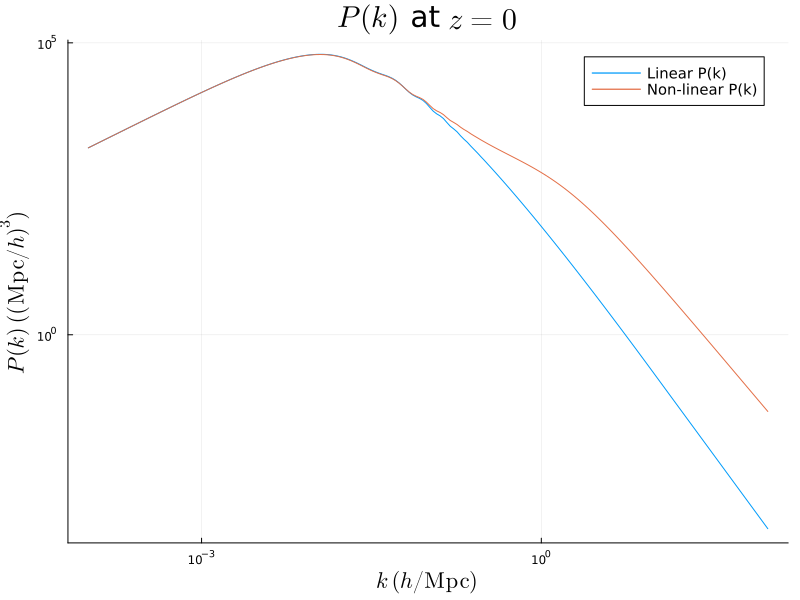

In [39]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

# println("Dimension of k points: ", size(k)[1])
# println("Dimension of Pklin: ", size(Pklin)[1])
# println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)

In [40]:
Nz = n_chi
k_grid = Blast.get_clencurt_grid(kmin, kmax, Nz)
kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz) # for the second integral in the double Bessel case
kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nz); # for the third integral in the double Bessel case

In [41]:
Pk_grid = power_spectrum_nl.(k_grid, first(z), last(z));
Nk = length(k_grid)
w_k = FastTransforms.clenshawcurtisweights(
      FastTransforms.chebyshevmoments1(Float64, Nk)) * (kmax - kmin) / 2
wktot = @. (2/pi) * w_k * k_grid^4 * Pk_grid;

In [42]:
println("size of wktot: ", size(wktot))
println("size of W_final: ", size(W_final))

size of wktot: (96,)
size of W_final: (100, 96, 96)


In [43]:
#heatmap(ℓ, z_range, W_final[:, 1, :], xlabel=L"\ell", ylabel="z", title=L"W_\ell(z_1, z_2) for $z_2 = $(z_range[1])$")

In [44]:
S_lkk = zeros(Float64, size(W_final, 3), size(W_final, 3), length(ℓ))
@tullio S_lkk[kp, kpp, li] := wktot[k] * W_final[li, k, kp] * W_final[li, kp, kpp];

In [45]:
npzwrite(joinpath(output_dir, "S_lkk.npy"), S_lkk)

In [46]:
println("Size of S_l (kp, kpp): ", size(S_lkk))

Size of S_l (kp, kpp): (96, 96, 100)


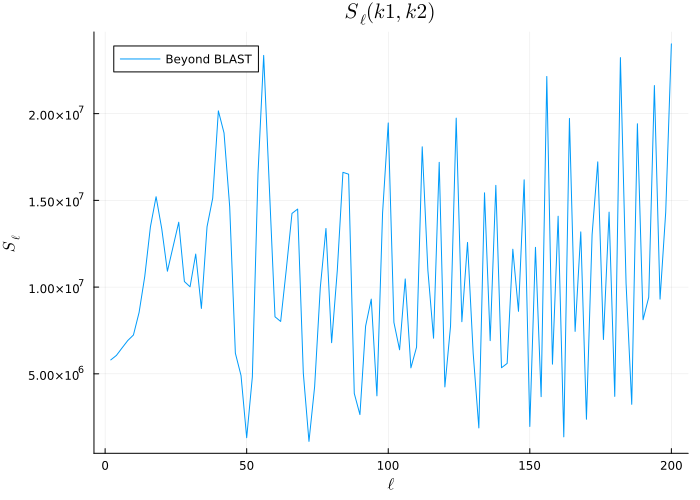

In [47]:
i = 2
j = 2
p = plot(
    ℓ,
    S_lkk[i, j, :],
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"S_\ell",
    title = L"S_\ell(k1, k2)",
    size = (700, 500)
)

In [48]:
S_l = zeros(Float64, length(ℓ))
@tullio S_l[li] := w_k[kp] * w_k[kpp] * S_lkk[kp, kpp, li];

In [49]:
npzwrite(joinpath(output_dir, "S_l.npy"), S_l)

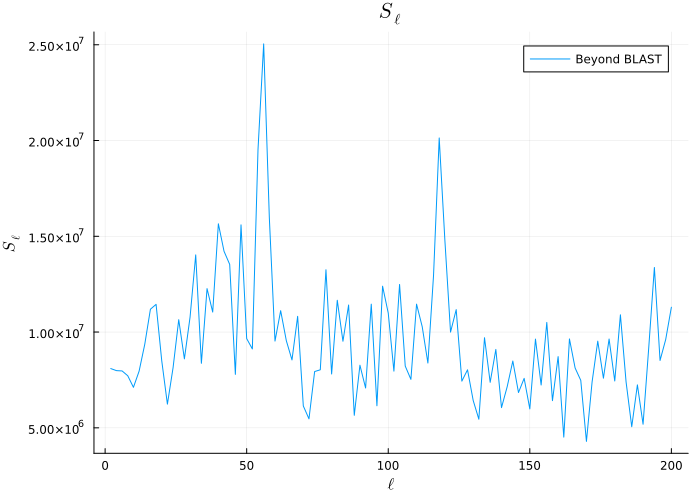

In [50]:
# plot
plot(ℓ, S_l, label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell",     size = (700, 500))

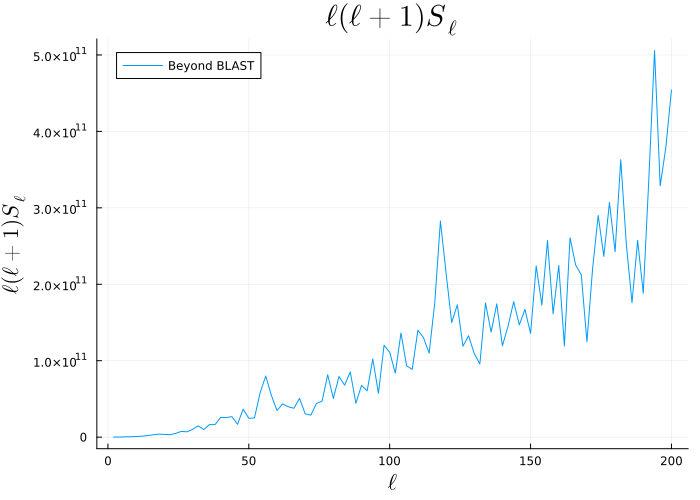

In [51]:
p = plot(
    ℓ,
    S_l .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15
)

In [52]:
p = plot(
    ℓ,
    S_l .* ℓ .* (ℓ .+ 1),
    label = L"N = $2^{15}+1$ with optimized $\tilde W$",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell",
    markersize=4,
    size = (700, 500),
    titlefontsize=20,
    labelfontsize=15,
    dpi = 200
)
savefig(p, "out/plots/S_l_plot.png")

"/Users/anvi/Desktop/cosmo/notebooks/out/plots/S_l_plot.png"

In [54]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "β" => β,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do io
    JSON.print(io, params_run, 4) # Scrive il dizionario in formato JSON pulito
end

println("Data brought to safety in folder: ", output_dir)

Data brought to safety in folder: out/runs/run_2026_06_12_100050
